In [72]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

In [73]:
df = pd.read_csv("./job_salary_prediction_dataset.csv")
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [74]:
print(df.shape)
display(df.info())
display(df.isna().sum().sort_values(ascending=False).head(10))

(250000, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB


None

job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

### Вариант 15:
Linear Regression |
Lasso |
KNN Regression |
XGBoost

## Прогнозируемая переменная - зарплата (salary)

Проверка значений строковых фичей - если значений не слишком много, используем transformer и оставим в датасете

In [75]:
for col in df.select_dtypes(include=["object"]).columns.tolist():
    print(f"--- Column: {col}")
    print(df[col].unique())
    print()

--- Column: job_title
['AI Engineer' 'Data Analyst' 'Frontend Developer' 'Business Analyst'
 'Product Manager' 'Backend Developer' 'Machine Learning Engineer'
 'DevOps Engineer' 'Software Engineer' 'Cybersecurity Analyst'
 'Data Scientist' 'Cloud Engineer']

--- Column: education_level
['Bachelor' 'PhD' 'High School' 'Diploma' 'Master']

--- Column: industry
['Healthcare' 'Telecom' 'Media' 'Retail' 'Manufacturing' 'Education'
 'Finance' 'Technology' 'Consulting' 'Government']

--- Column: company_size
['Medium' 'Small' 'Large' 'Enterprise' 'Startup']

--- Column: location
['India' 'Australia' 'Singapore' 'Canada' 'Sweden' 'USA' 'Netherlands'
 'Remote' 'Germany' 'UK']

--- Column: remote_work
['Hybrid' 'No' 'Yes']



Все признаки содержат довольно мало значений, и нет нужны их подгатавливать к энкодингу, тк нет дубликатов (одного значения с разным написанием)

Также в самом датасете нет пропусков - иной обработки не требуется

Масштабирование: необходимо для линейных моделей (LinearRegression, Lasso, Ridge)

In [76]:
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = df.select_dtypes(exclude=["object"]).columns.tolist()

if target_col in numeric_cols:
    numeric_cols.remove(target_col)

print("Категориальные признаки:", categorical_cols)
print("Числовые признаки:", numeric_cols)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
    ],
    remainder='drop'
)


X = df.drop(columns=[target_col])
y = df[target_col]
X_transformed = preprocessor.fit_transform(X)

feature_names = (
    numeric_cols +
    list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols))
)

X = pd.DataFrame(X_transformed, columns=feature_names)
X.head

Категориальные признаки: ['job_title', 'education_level', 'industry', 'company_size', 'location', 'remote_work']
Числовые признаки: ['experience_years', 'skills_count', 'certifications']


<bound method NDFrame.head of         experience_years  skills_count  certifications  \
0              -0.000892     -1.459647       -0.288272   
1              -0.825894      1.277940       -1.460281   
2               1.319111     -1.094636       -0.874276   
3               1.484112      0.547917       -1.460281   
4               0.824110     -0.547118       -1.460281   
...                  ...           ...             ...   
249995          1.154111     -1.459647       -0.874276   
249996          1.649112     -0.547118       -0.288272   
249997         -1.485896      0.365411       -1.460281   
249998         -1.650897     -1.459647        1.469741   
249999          0.989110     -1.459647        1.469741   

        job_title_Backend Developer  job_title_Business Analyst  \
0                               0.0                         0.0   
1                               0.0                         0.0   
2                               0.0                         0.0   
3    

In [77]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape)

(200000, 42) (50000, 42)


## Анализ факторов

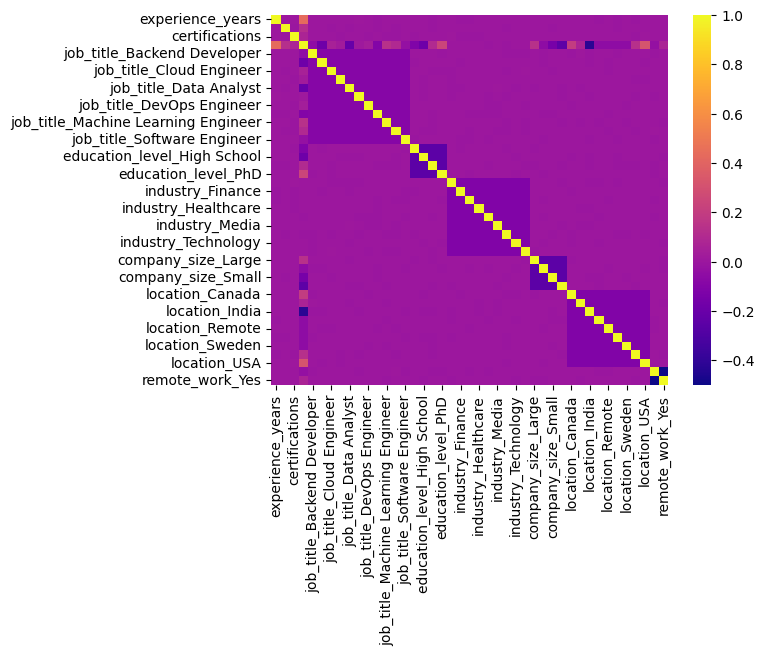

In [78]:
sns.heatmap(dft.corr(), cmap="plasma")
plt.show()

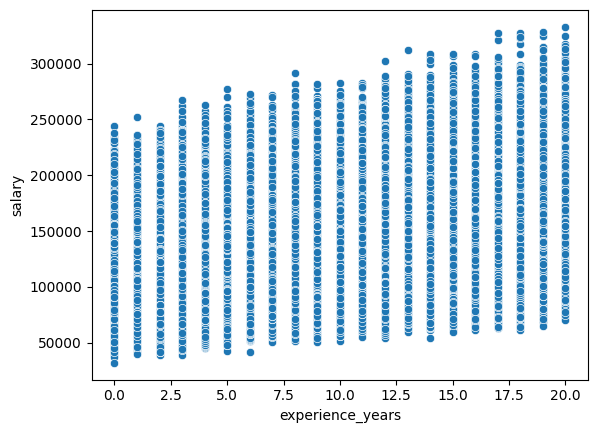

In [79]:
sns.scatterplot(data=df, x="experience_years", y="salary")
plt.show()

## Выбор значимых признаков

In [80]:
selector = SelectKBest(score_func=f_regression, k=10)
X_selected = selector.fit_transform(X, y)
selected_features = X.columns[selector.get_support()].tolist()

feature_scores = pd.DataFrame({
    'feature': X.columns,
    'f_score': selector.scores_
}).sort_values('f_score', ascending=False)

feature_scores

,feature,f_score
0,experience_years,59220.819249
33,location_India,55734.739892
39,location_USA,28575.937801
30,company_size_Startup,15981.246036
17,education_level_PhD,15771.289936
7,job_title_Data Analyst,11254.624451
31,location_Canada,9759.341015
15,education_level_High School,9090.628647
4,job_title_Business Analyst,8940.885484
29,company_size_Small,5936.624186


## Последовательно берем первые i факторов из ordered_features, и смотрим на точность модели, для определения необходимого набора для обучения

In [160]:
models = []

def checkForModel(model, step=8):
    results = []
    models = []
    
    for i in range(2, len(feature_scores.feature) + 1, step):
        features_i = feature_scores.feature[:i]
    
        Xtr = X_train[features_i]
        Xte = X_test[features_i]
    
        model_i = model()
        model_i.fit(Xtr, y_train)
        models.append(model_i)
    
        y_pred_train = model_i.predict(Xtr)
        y_pred_test  = model_i.predict(Xte)
    
        r2_tr   = r2_score(y_train, y_pred_train)
        r2_te   = r2_score(y_test,  y_pred_test)
        mae_te  = mean_absolute_error(y_test, y_pred_test)
        rmse_te = np.sqrt(mean_squared_error(y_test, y_pred_test))

        results.append({
            "n_features" : i,
            "features"   : ", ".join(features_i),
            "R2_train"   : round(r2_tr,  4),
            "R2_test"    : round(r2_te,  4),
            "MAE_test"   : round(mae_te, 2),
            "RMSE_test"  : round(rmse_te, 2)
        })

    return results, models

### LinearRegression

In [161]:
results, models = checkForModel(LinearRegression, step=4)
lr_results = pd.DataFrame(results)
lr_results.sort_values('R2_test', ascending=False)

,n_features,features,R2_train,R2_test,MAE_test,RMSE_test
8,34,"experience_years, location_India, location_USA...",0.9634,0.9635,5435.76,7125.12
9,38,"experience_years, location_India, location_USA...",0.9634,0.9635,5436.08,7125.50
10,42,"experience_years, location_India, location_USA...",0.9634,0.9635,5436.10,7125.52
7,30,"experience_years, location_India, location_USA...",0.9266,0.9258,7526.09,10156.15
6,26,"experience_years, location_India, location_USA...",0.9178,0.9165,7922.18,10774.36
5,22,"experience_years, location_India, location_USA...",0.8610,0.8605,10698.16,13922.10
4,18,"experience_years, location_India, location_USA...",0.8396,0.8376,11631.75,15022.00
3,14,"experience_years, location_India, location_USA...",0.7997,0.7987,13033.72,16728.63
2,10,"experience_years, location_India, location_USA...",0.7529,0.7513,14577.77,18590.74
1,6,"experience_years, location_India, location_USA...",0.6115,0.6086,18400.83,23323.70


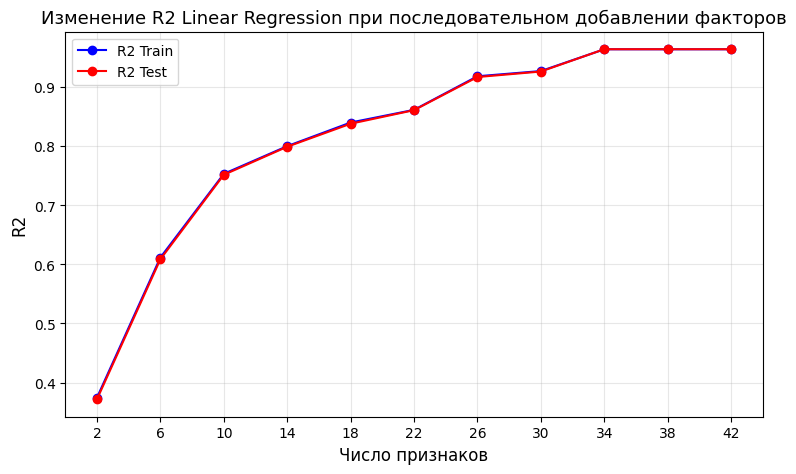

In [162]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(lr_results["n_features"], lr_results["R2_train"], "o-", label="R2 Train", c="b")
ax.plot(lr_results["n_features"], lr_results["R2_test"],  "o-", label="R2 Test",  c="r")

ax.set_xlabel("Число признаков", fontsize=12)
ax.set_ylabel("R2", fontsize=12)
ax.set_title("Изменение R2 Linear Regression при последовательном добавлении факторов", fontsize=13)
ax.legend()

ax.set_xticks(lr_results["n_features"])
ax.grid(True, alpha=0.3)

plt.show()

In [171]:
def show_linear_coefficients(model, feature_names, model_name="Linear Model"):
    """ Показывает коэффициенты линейной модели """
    print(f"\n{'=' * 50}")
    print(f"КОЭФФИЦИЕНТЫ МОДЕЛИ: {model_name}")
    print('=' * 50)

    coef_df = pd.DataFrame({
        'Признак': list(feature_names),
        'Коэффициент': list(model.coef_)
    })
    
    coef_df['Абс_коэф'] = coef_df['Коэффициент'].abs()
    coef_df = coef_df.sort_values('Абс_коэф', ascending=False).drop('Абс_коэф', axis=1)

    print(coef_df.to_string(index=False))
    print(f"Свободный член ({model.intercept_:.2f})")

    print(f"\nТОП-5 самых влиятельных признаков:")
    top_features = coef_df[coef_df['Признак'] != 'intercept'].head(5)
    for idx, row in top_features.iterrows():
        print(f"  {row['Признак']}")

In [172]:
for i, model in enumerate(models):
    feats = len(model.coef_)
    features_used = ordered_features[:feats]
    show_linear_coefficients(model, features_used, f"Linear Model с {feats} признаками")


КОЭФФИЦИЕНТЫ МОДЕЛИ: Linear Model с 2 признаками
         Признак   Коэффициент
  location_India -53418.859678
experience_years  16447.045118
Свободный член (151029.08)

ТОП-5 самых влиятельных признаков:
  location_India
  experience_years

КОЭФФИЦИЕНТЫ МОДЕЛИ: Linear Model с 6 признаками
               Признак   Коэффициент
        location_India -49533.916021
          location_USA  34437.229225
job_title_Data Analyst -28142.325611
  company_size_Startup -22932.575460
   education_level_PhD  22859.631608
      experience_years  16402.420132
Свободный член (149548.52)

ТОП-5 самых влиятельных признаков:
  location_India
  location_USA
  job_title_Data Analyst
  company_size_Startup
  education_level_PhD

КОЭФФИЦИЕНТЫ МОДЕЛИ: Linear Model с 10 признаками
                    Признак   Коэффициент
             location_India -46698.049936
               location_USA  37268.439364
     job_title_Data Analyst -30612.892539
       company_size_Startup -28266.388341
 job_title_Business Ana

### Lasso

In [150]:
results_lasso, models = checkForModel(lambda: Lasso(alpha=.8, max_iter=2000), step=4)
lasso_results = pd.DataFrame(results_lasso)
lasso_results.sort_values('R2_test', ascending=False)

,n_features,features,R2_train,R2_test,MAE_test,RMSE_test
8,34,"experience_years, location_India, location_USA...",0.9634,0.9635,5435.73,7125.43
9,38,"experience_years, location_India, location_USA...",0.9634,0.9635,5435.99,7125.76
10,42,"experience_years, location_India, location_USA...",0.9634,0.9635,5436.06,7125.82
7,30,"experience_years, location_India, location_USA...",0.9266,0.9258,7524.99,10156.14
6,26,"experience_years, location_India, location_USA...",0.9178,0.9165,7921.69,10774.28
5,22,"experience_years, location_India, location_USA...",0.8610,0.8605,10697.45,13922.07
4,18,"experience_years, location_India, location_USA...",0.8396,0.8376,11631.23,15021.93
3,14,"experience_years, location_India, location_USA...",0.7997,0.7987,13033.40,16728.59
2,10,"experience_years, location_India, location_USA...",0.7529,0.7513,14577.51,18590.68
1,6,"experience_years, location_India, location_USA...",0.6115,0.6086,18400.67,23323.65


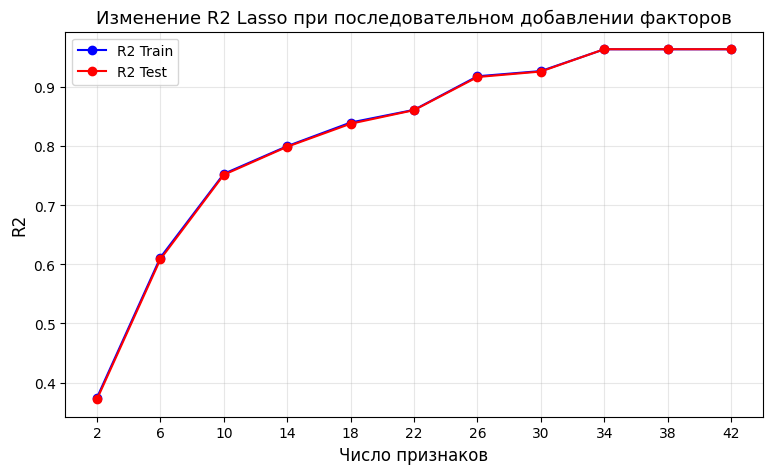

In [151]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(lasso_results["n_features"], lasso_results["R2_train"], "o-", label="R2 Train", c="b")
ax.plot(lasso_results["n_features"], lasso_results["R2_test"],  "o-", label="R2 Test",  c="r")

ax.set_xlabel("Число признаков", fontsize=12)
ax.set_ylabel("R2", fontsize=12)
ax.set_title("Изменение R2 Lasso при последовательном добавлении факторов", fontsize=13)

ax.legend()
ax.set_xticks(lasso_results["n_features"])
ax.grid(True, alpha=0.3)

plt.show()

### KNN Regression

In [152]:
results_knn, _ = checkForModel(lambda: KNeighborsRegressor(n_neighbors=3))
knn_results = pd.DataFrame(results_knn)
knn_results.sort_values('R2_test', ascending=False)

,n_features,features,R2_train,R2_test,MAE_test,RMSE_test
3,26,"experience_years, location_India, location_USA...",0.9443,0.8851,9581.06,12636.79
4,34,"experience_years, location_India, location_USA...",0.9432,0.8811,9819.99,12856.85
2,18,"experience_years, location_India, location_USA...",0.8669,0.8012,12515.41,16620.83
5,42,"experience_years, location_India, location_USA...",0.8938,0.7977,13006.56,16767.89
1,10,"experience_years, location_India, location_USA...",0.6766,0.6701,16521.77,21413.72
0,2,"experience_years, location_India",0.0922,0.0904,28212.91,35556.18


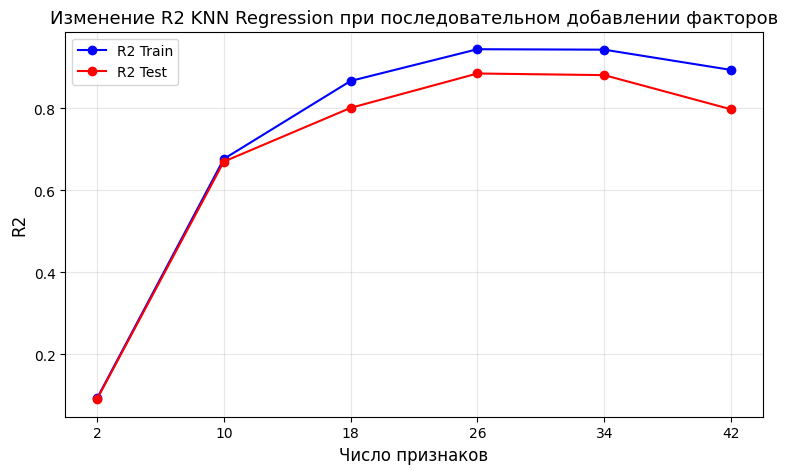

In [153]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(knn_results["n_features"], knn_results["R2_train"], "o-", label="R2 Train", c="b")
ax.plot(knn_results["n_features"], knn_results["R2_test"],  "o-", label="R2 Test",  c="r")
ax.set_xlabel("Число признаков", fontsize=12)
ax.set_ylabel("R2", fontsize=12)
ax.set_title("Изменение R2 KNN Regression при последовательном добавлении факторов", fontsize=13)
ax.legend()
ax.set_xticks(knn_results["n_features"])
ax.grid(True, alpha=0.3)
plt.show()

### XGBoost

In [154]:
results_xgb, _ = checkForModel(lambda: XGBRegressor(n_estimators=10, random_state=42, verbosity=0))
xgb_results = pd.DataFrame(results_xgb)
xgb_results.sort_values('R2_test', ascending=False)

,n_features,features,R2_train,R2_test,MAE_test,RMSE_test
4,34,"experience_years, location_India, location_USA...",0.8585,0.8573,10891.50,14084.31
5,42,"experience_years, location_India, location_USA...",0.8585,0.8573,10891.55,14084.34
3,26,"experience_years, location_India, location_USA...",0.8509,0.8493,11207.83,14474.24
2,18,"experience_years, location_India, location_USA...",0.8113,0.8091,12644.97,16287.24
1,10,"experience_years, location_India, location_USA...",0.7513,0.7498,14550.87,18648.92
0,2,"experience_years, location_India",0.3769,0.3742,23234.05,29491.68


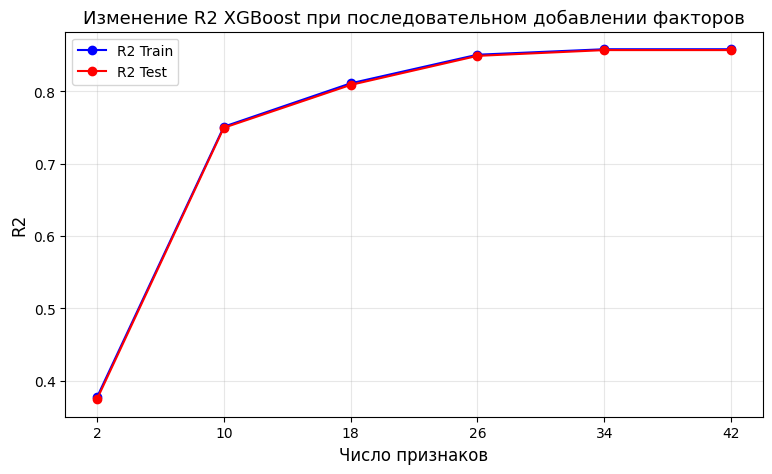

In [155]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(xgb_results["n_features"], xgb_results["R2_train"], "o-", label="R2 Train", c="b")
ax.plot(xgb_results["n_features"], xgb_results["R2_test"],  "o-", label="R2 Test",  c="r")
ax.set_xlabel("Число признаков", fontsize=12)
ax.set_ylabel("R2", fontsize=12)
ax.set_title("Изменение R2 XGBoost при последовательном добавлении факторов", fontsize=13)
ax.legend()
ax.set_xticks(xgb_results["n_features"])
ax.grid(True, alpha=0.3)
plt.show()

## Общий график для всех моделей, для R2 на тестовой выборке

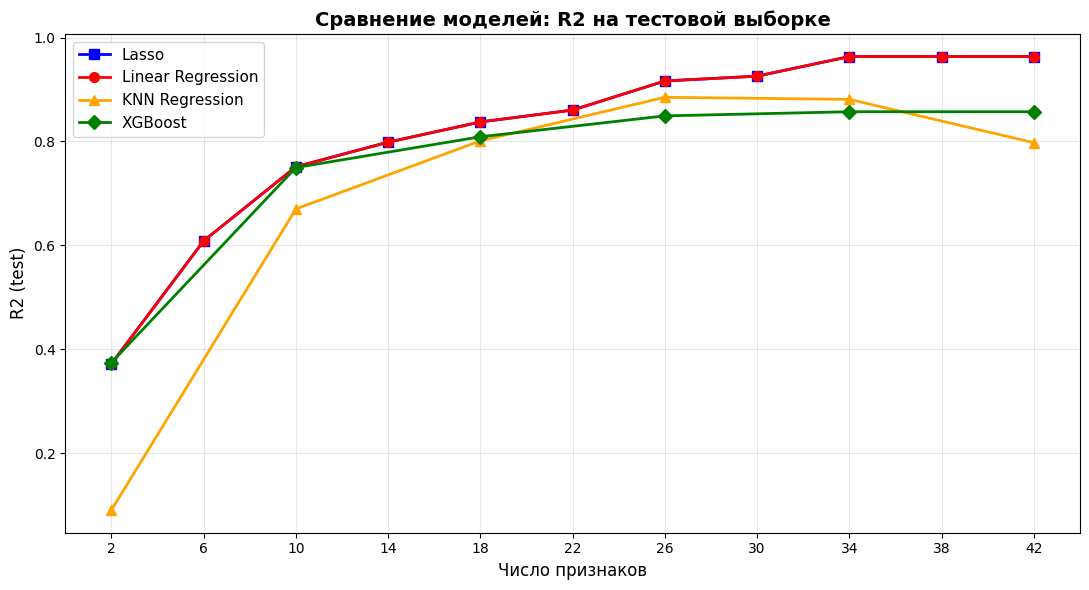

In [156]:
fig, ax = plt.subplots(figsize=(11, 6))

models_data = [
    (lasso_results, "Lasso",             "s-", "b"),
    (lr_results,    "Linear Regression", "o-", "r"),
    (knn_results,   "KNN Regression",    "^-", "orange"),
    (xgb_results,   "XGBoost",           "D-", "g"),
]

for df_res, label, marker, color in models_data:
    ax.plot(df_res["n_features"], df_res["R2_test"],
            marker, label=label, color=color, linewidth=2, markersize=7)

ax.set_xlabel("Число признаков", fontsize=12)
ax.set_ylabel("R2 (test)", fontsize=12)
ax.set_title("Сравнение моделей: R2 на тестовой выборке", fontsize=14, fontweight="bold")

ax.legend(fontsize=11)
ax.set_xticks(lr_results["n_features"])
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Анализ качества моделей:
На общем графике сравнения моделей по метрике R2 на тестовой выборке хорошо видны ключевые закономерности:
- Лучшие результаты показывают Linear Regression и Lasso - почти идентичное поведение с R2 ~ 0.96, что говорит о высоком качестве предсказаний и отсутствии переобучения. Признаки были тщательно отобраны по значимости, а линейные модели показывают стабильную работу на масштабированных данных.
- KNN Regression показывает хорошие результаты (R2 ~ 0.89). Нелинейная кривая объясняется особенностью метода.
- XGBoost показывает неплохие результаты (R2 ~ 0.86) с ростом качества при увеличении числа признаков. Градиентный буст эффективно работает с большим количеством признаков, но требует больше данных для оптимальной настройки

### Выводы по стабильности:
Отсутствие значительной разницы между R2_train и R2_test у всех моделей указывает на отсутствие переобучения

### LinearRegression и Lasso выдают очень схожий результат

## Для наиболее важных признаков построим поверхность предсказаний

In [138]:
feat1 = feature_scores.feature.iloc[0]
feat2 = feature_scores.feature.iloc[1]

print(f"Топ-1 признак: '{feat1}'")
print(f"Топ-2 признак: '{feat2}'")

X2_train = X_train[[feat1, feat2]]
X2_test = X_test[[feat1, feat2]]

Топ-1 признак: 'experience_years'
Топ-2 признак: 'location_India'


In [141]:
def makePlot(model):
    surf_model = model.fit(X2_train, y_train)
    y_pred_surf = surf_model.predict(X2_test)

    r2_surf = r2_score(y_test, y_pred_surf)
    mae_surf = mean_absolute_error(y_test, y_pred_surf)
    rmse_surf = np.sqrt(mean_squared_error(y_test, y_pred_surf))

    f1_range = np.linspace(X_train[feat1].min(), X_train[feat1].max(), 80)
    f2_range = np.linspace(X_train[feat2].min(), X_train[feat2].max(), 80)
    F1, F2 = np.meshgrid(f1_range, f2_range)

    grid_df = pd.DataFrame({feat1: F1.ravel(), feat2: F2.ravel()})
    Z = surf_model.predict(grid_df).reshape(F1.shape)

    fig = plt.figure(figsize=(12, 7))
    ax  = fig.add_subplot(1, 1, 1, projection="3d")

    ax.scatter(
        X_test[feat1].values,
        X_test[feat2].values,
        y_test.values,
        c="cyan", alpha=0.008)

    surf = ax.plot_surface(
        F1, F2, Z,
        cmap="plasma", alpha=0.6,
        edgecolor="none")

    fig.colorbar(surf, ax=ax, shrink=0.45, pad=0.1)

    ax.set_xlabel(feat1, fontsize=10, labelpad=8)
    ax.set_ylabel(feat2, fontsize=10, labelpad=8)
    ax.set_zlabel(target_col, fontsize=10, labelpad=8)
    ax.set_title(f"Поверхность предсказаний для {model.__class__.__name__}")

    ax.view_init(elev=10, azim=240)

    plt.tight_layout()
    plt.show()

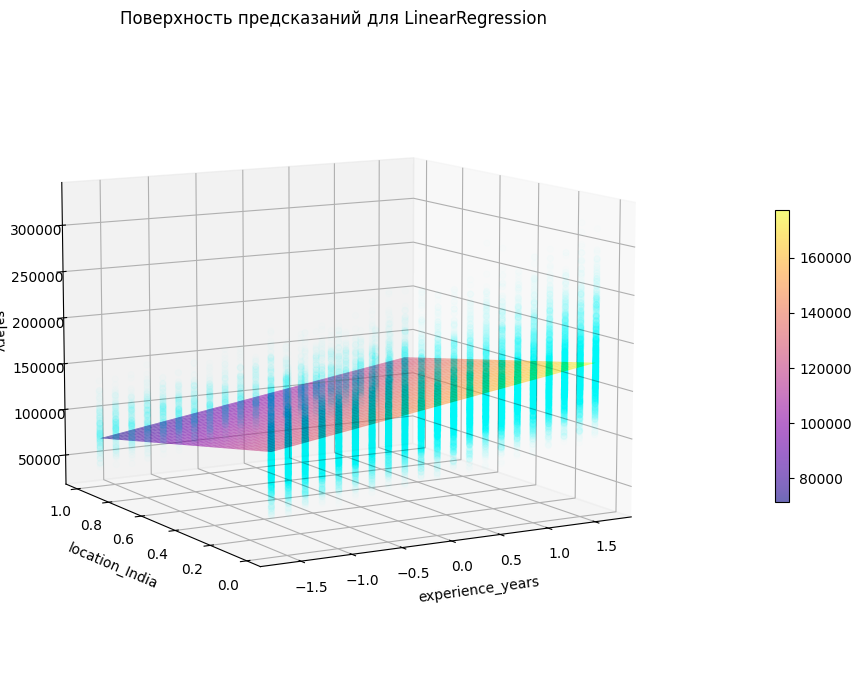

In [142]:
makePlot(LinearRegression())

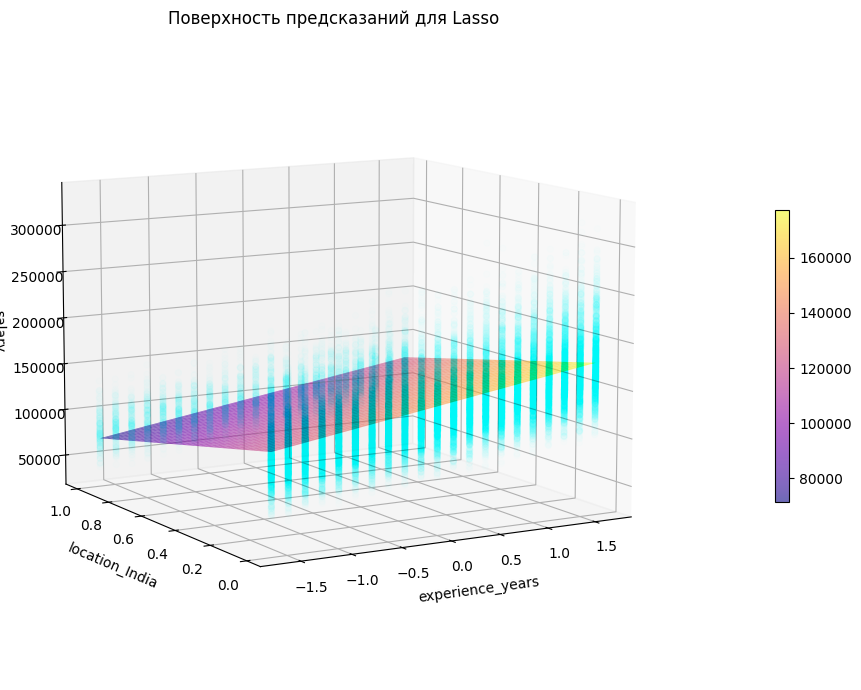

In [143]:
makePlot(Lasso(alpha=.8, max_iter=2000))

### Анализ для Linear и Lasso
- Поверхность представляет собой плоскость (линейная зависимость)
- Четко видна линейная зависимость от опыта работы
- Различия в уровнях зарплат между регионами (India/не India)
- Гладкая поверхность показывает стабильность линейной модели

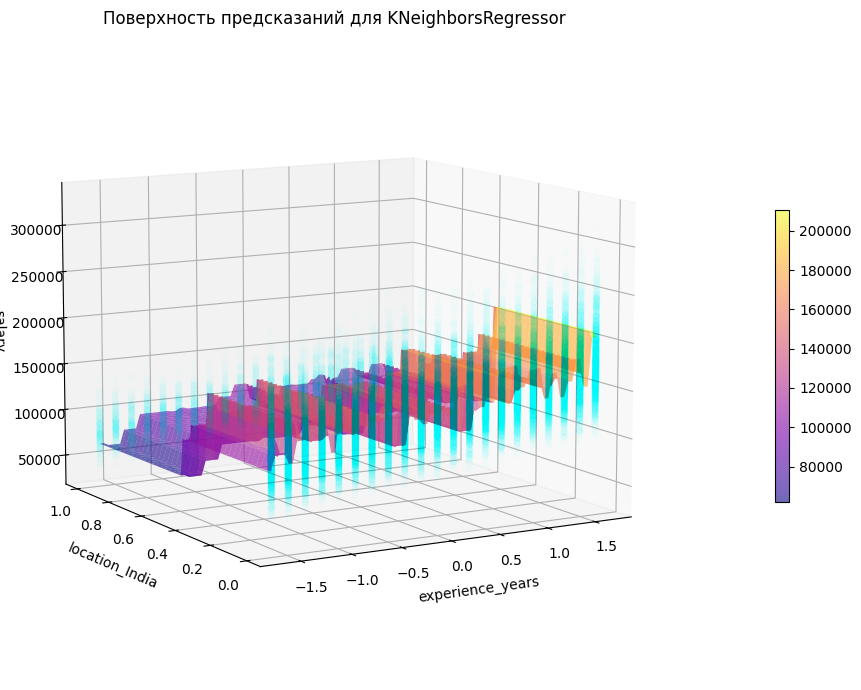

In [144]:
makePlot(KNeighborsRegressor(n_neighbors=5))

### Анализ для KNeighborsRegressor
- Поверхность имеет ступенчатую структуру (локальные средние)
- Видны регионы с похожими зарплатами (эффект ближайших соседей)
- Более "зернистая" структура по сравнению с линейными моделями
- Улавливает нелинейные зависимости в данных

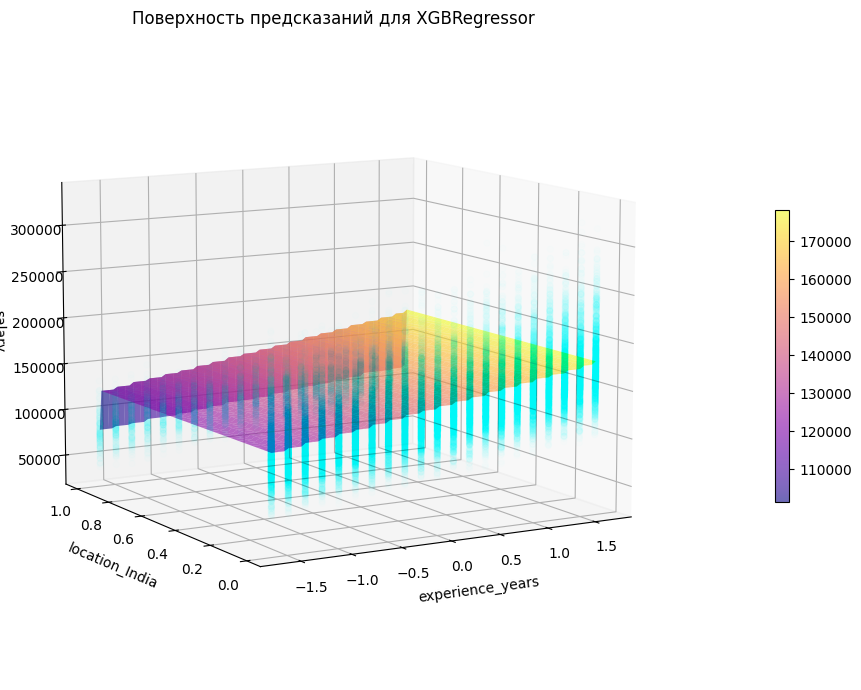

In [145]:
makePlot(XGBRegressor(n_estimators=100, random_state=42, verbosity=0))

### Анализ для XGBRegressor
- Поверхность демонстрирует сложные нелинейные зависимости
- Видны области с резкими изменениями предсказаний
- Учитывает взаимодействия между признаками
- Более детализированная структура по сравнению с линейными моделями

## Выводы

Основные результаты:

Предобработка данных:
   - Категориальные признаки закодированы с помощью OneHotEncoder
   - Числовые признаки масштабированы StandardScaler
   - Пропущенные значения отсутствуют


Анализ значимости признаков:
- Наиболее влиятельные факторы: experience_years, location_India, location_USA, job_title_Data Analyst
- Использован SelectKBest для отбора значимых параметров


Сравнение моделей:
- Лучший результат: Linear Regression и Lasso (R2 ~ 0.96 при 8 признаках)
- Хорошие результаты: KNN (R2 ~ 0.89) и XGBoost (R2 ~ 0.86)
- Переобучение не наблюдается


Интерпретация модели:
- Ключевые факторы увеличивающие зарплату: работа в США, наличие PhD, опыт работы
- Ключевые факторы уменьшающие зарплату: работа в Индии, позиции Data Analyst/Business Analyst
- Свободный член: базовый уровень зарплаты при нулевых значениях признаков


Практическая значимость:
- Модель показывает высокую точность прогнозирования (R2 > 0.96)
- Построены 3D-поверхности предсказаний для визуализации влияния ключевых факторов
- Разработанная модель может использоваться для прогнозирования зарплат в HR-аналитике